# Ames House Prices: EDA -> Preprocessing -> Feature Engineering -> Modeling -> Submission

An end-to-end walkthrough for the [House Prices - Advanced Regression
Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)
competition: explore the data, build a leak-free preprocessing/feature
pipeline, train four from-scratch gradient-descent regressors against
their scikit-learn counterparts, select hyperparameters with 5-fold
cross-validation, and produce a submission file.

This notebook is a condensed version of a larger project
([source repo](https://github.com/akakritagya/ames-price)) whose EDA and
modeling live in a dozen focused notebooks; every finding and number
quoted here was produced there and is reproduced/re-run in this single
file for a self-contained walkthrough.

**Result:** scikit-learn `Lasso` (alpha=0.003162) is the best model, RMSE
0.113 (log space) / R² 0.924 on a held-out split, confirmed by 5-fold CV.

**A convention held throughout:** the EDA section only observes -- no
`fillna`, transform, encoding, or row drop happens there. Every one of
those actions is applied later, in the Preprocessing & Feature
Engineering section, by code that is fit on training data only and
applied to validation/test with `transform`, never `fit_transform`, to
avoid leaking information across the split.


## Setup

This notebook reuses the source project's own tested code
(`ames_price.*` -- the `Imputer`/`FeatureEngineer`/`Encoder`/GD model
classes) rather than reimplementing it inline, so what's demonstrated
here is identical to what the source repo's test suite covers. It's a
public package, installed straight from GitHub, and the cell below skips
the install entirely if `ames_price` is already importable (e.g. running
this notebook inside a clone of the source repo).

In [1]:
try:
    import ames_price  # noqa: F401
except ImportError:
    %pip install -q "git+https://github.com/akakritagya/ames-price.git"


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

from ames_price.constants import NOMINAL_COLS, NUMERIC_COLS, ORDER, ORDINAL_COLS
from ames_price.model_selection import kfold_split
from ames_price.models.elastic_net_gd import ElasticNetGD
from ames_price.models.lasso_gd import LassoGD
from ames_price.models.linear_regression import LinearRegressionGD
from ames_price.models.ridge_gd import RidgeGD
from ames_price.pipeline import build_pipeline

FEATURE_COLS = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS
RANDOM_STATE = 42

plt.rcParams["figure.dpi"] = 100


Data can come from two places depending on where this runs: Kaggle
mounts the competition files under `/kaggle/input/...`, while running
this notebook from a clone of the source repo finds them under
`data/`. The cell below tries both so the rest of the notebook doesn't
care which environment it's in.

In [ ]:
_DATA_CANDIDATES = [
    Path("/kaggle/input/house-prices-advanced-regression-techniques"),
    Path("/kaggle/input/competitions/house-prices-advanced-regression-techniques"),
    Path("../../data"),
    Path("data"),
]
DATA_DIR = next(p for p in _DATA_CANDIDATES if (p / "train.csv").exists())

df_train = pd.read_csv(DATA_DIR / "train.csv")
df_test = pd.read_csv(DATA_DIR / "test.csv")
df_train.shape, df_test.shape


((1460, 81), (1459, 80))

## 1. Exploratory Data Analysis

Observational only -- every fill/transform/drop decision this section
motivates gets *applied* in the Preprocessing & Feature Engineering
section below, not here.

### 1.1 A first look

In [4]:
df_train.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df_train.info(memory_usage=False)


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### 1.2 Target variable: `SalePrice`

Raw `SalePrice` is heavily right-skewed. `log1p` brings it close to
normal and roughly halves the IQR-outlier count -- so every model in
this notebook is trained on `log_sale_price = np.log1p(SalePrice)`, and
predictions are `expm1`-transformed back to dollars for reporting.

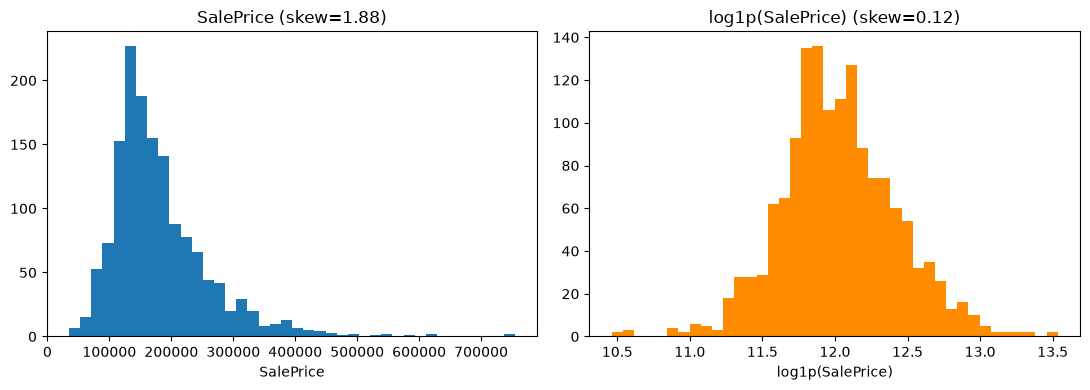

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df_train["SalePrice"], bins=40)
axes[0].set_title(f"SalePrice (skew={df_train['SalePrice'].skew():.2f})")
axes[0].set_xlabel("SalePrice")

log_sale_price = np.log1p(df_train["SalePrice"])
axes[1].hist(log_sale_price, bins=40, color="darkorange")
axes[1].set_title(f"log1p(SalePrice) (skew={log_sale_price.skew():.2f})")
axes[1].set_xlabel("log1p(SalePrice)")
plt.tight_layout()
plt.show()


### 1.3 Missingness

Every `NaN` in this dataset falls into one of two buckets, verified on
both train and test:

| Bucket | Meaning | Handling |
|---|---|---|
| **Structural absence** | The feature genuinely doesn't apply (no pool, no alley, no basement, no garage, no fireplace, no masonry veneer) | `fillna("None")` / `fillna(0)` -- it isn't missing, it's "doesn't exist" |
| **Real gap** | The feature applies but wasn't recorded | Needs an actual imputation strategy (median/mode/group-based) |

For example, every row with `GarageArea == 0` and `GarageCars == 0` also
has `GarageType` (and the rest of the garage group) as `NaN` -- confirming
structural absence rather than an unknown value. The real gaps are
`LotFrontage` (~17% missing, tracks `LotConfig`), `Electrical` (1 row),
and 7 test-only categoricals, each with a dominant category.

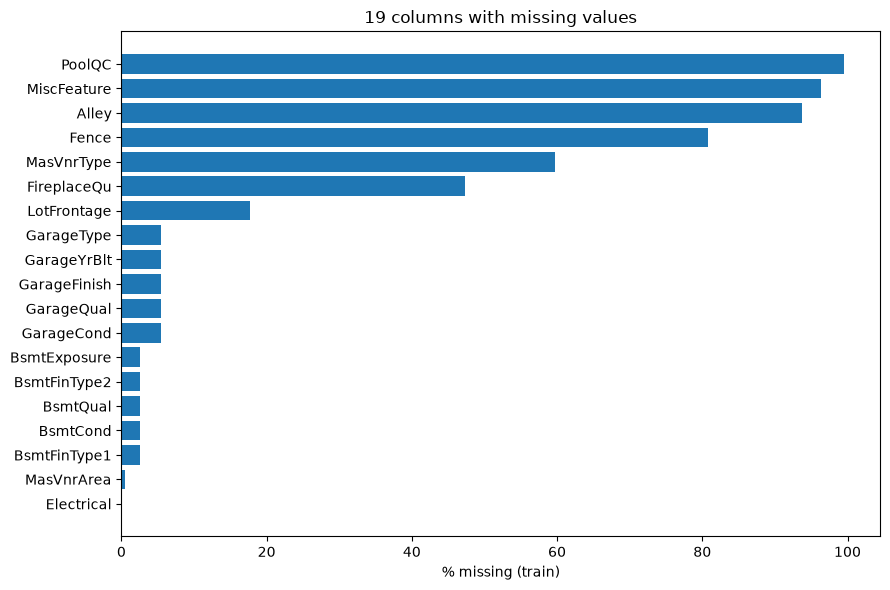

In [7]:
missing = df_train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df_train) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(missing.index[::-1], missing_pct.values[::-1])
ax.set_xlabel("% missing (train)")
ax.set_title(f"{len(missing)} columns with missing values")
plt.tight_layout()
plt.show()


### 1.4 Univariate: an example skewed feature and a high-cardinality category

Across all 33 numeric columns, 75% are skewed or zero-heavy enough to
flag as log/has-X transform candidates (`GrLivArea` below is one); across
the 25 nominal columns, 72% have a rare category under 1% of rows worth
bucketing (`Neighborhood`, with 25 levels, is the highest-cardinality
example).

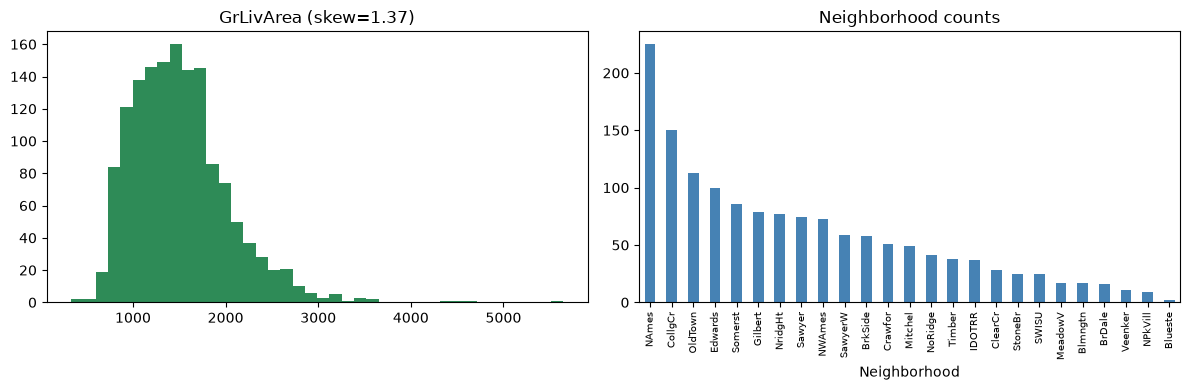

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_train["GrLivArea"], bins=40, color="seagreen")
axes[0].set_title(f"GrLivArea (skew={df_train['GrLivArea'].skew():.2f})")

df_train["Neighborhood"].value_counts().plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Neighborhood counts")
axes[1].tick_params(axis="x", labelrotation=90, labelsize=7)
plt.tight_layout()
plt.show()


### 1.5 Bivariate: what correlates with price

Ordinals are integer-encoded on their documented `data_description.txt`
order (structural-absence `NaN` excluded, not a rank position) so
Spearman correlation reads them on the intended scale rather than raw
string order.

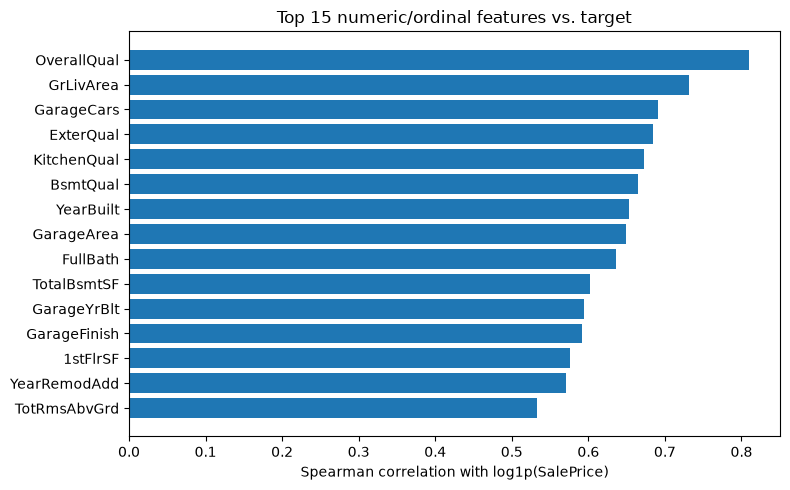

In [9]:
ordinal_encoded = df_train[ORDINAL_COLS].copy()
for col in ORDINAL_COLS:
    order = [lvl for lvl in ORDER[col] if lvl != "None"]
    ordinal_encoded[col] = ordinal_encoded[col].map(
        {level: i for i, level in enumerate(order)}
    )

numeric_and_ordinal = pd.concat([df_train[NUMERIC_COLS], ordinal_encoded], axis=1)
correlations = numeric_and_ordinal.apply(
    lambda col: spearmanr(col, log_sale_price, nan_policy="omit").statistic
)
top_correlations = correlations.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_correlations.index[::-1], correlations[top_correlations.index][::-1])
ax.set_xlabel("Spearman correlation with log1p(SalePrice)")
ax.set_title("Top 15 numeric/ordinal features vs. target")
plt.tight_layout()
plt.show()


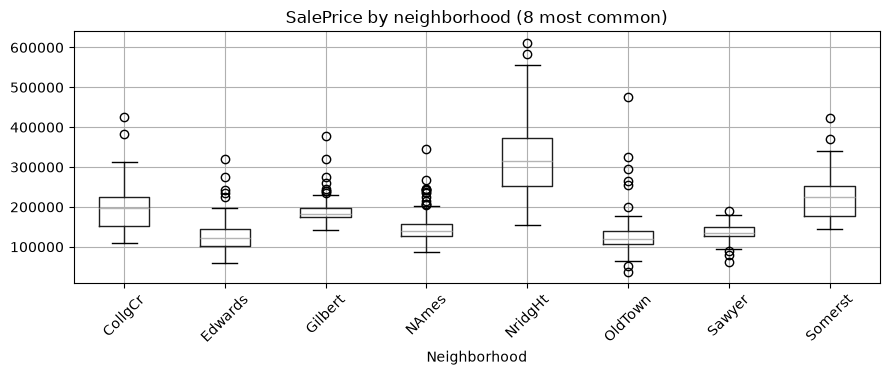

In [10]:
top_neighborhoods = df_train["Neighborhood"].value_counts().head(8).index
fig, ax = plt.subplots(figsize=(9, 4))
df_train[df_train["Neighborhood"].isin(top_neighborhoods)].boxplot(
    column="SalePrice", by="Neighborhood", ax=ax, rot=45
)
ax.set_title("SalePrice by neighborhood (8 most common)")
plt.suptitle("")
plt.tight_layout()
plt.show()


### 1.6 Multicollinearity

Two structural identities hold for 100% of rows -- not correlation, a
data-generating identity -- so a linear model shouldn't get both a total
and every part that sums to it:

- `TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF`
- `GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF`

`GarageArea`/`GarageCars` (near-duplicate size measures) and
`GarageYrBlt`/`YearBuilt` are also strongly correlated. The heatmap below
shows this cluster plus the broader quality-ordinal group.

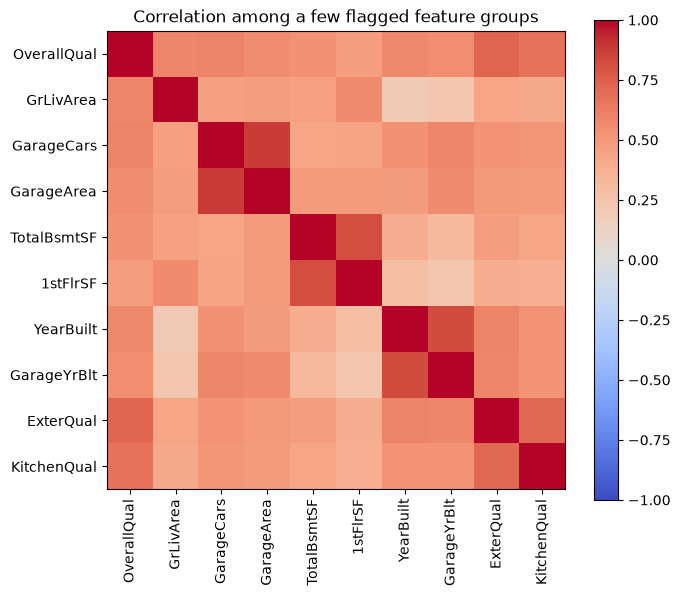

In [11]:
collinearity_cols = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea", "TotalBsmtSF",
    "1stFlrSF", "YearBuilt", "GarageYrBlt", "ExterQual", "KitchenQual",
]
corr_matrix = numeric_and_ordinal[collinearity_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(collinearity_cols)))
ax.set_xticklabels(collinearity_cols, rotation=90)
ax.set_yticks(range(len(collinearity_cols)))
ax.set_yticklabels(collinearity_cols)
fig.colorbar(im, ax=ax)
ax.set_title("Correlation among a few flagged feature groups")
plt.tight_layout()
plt.show()


### 1.7 Outliers

Three independent methods (univariate IQR, regression-residual, and
`IsolationForest`) triangulate on the same two rows: `Id` 524 and 1299,
both maximum-quality new-construction sales priced far below what their
size predicts. They're dropped before training below.

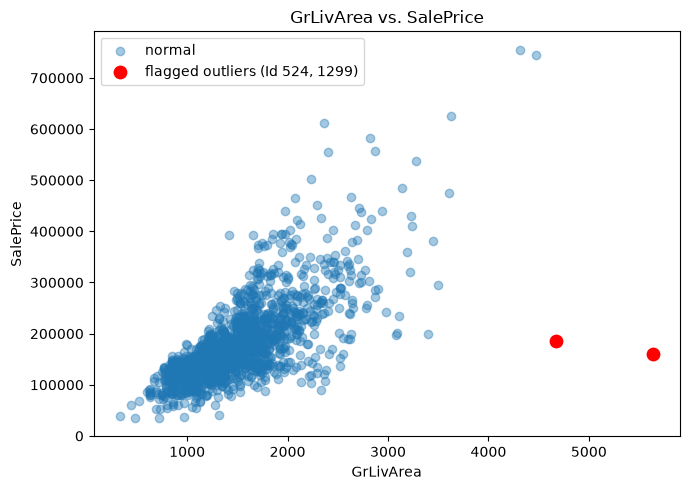

In [12]:
outlier_ids = [524, 1299]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_train["GrLivArea"], df_train["SalePrice"], alpha=0.4, label="normal")
outliers = df_train[df_train["Id"].isin(outlier_ids)]
ax.scatter(outliers["GrLivArea"], outliers["SalePrice"], color="red", s=80,
           label="flagged outliers (Id 524, 1299)")
ax.set_xlabel("GrLivArea")
ax.set_ylabel("SalePrice")
ax.legend()
ax.set_title("GrLivArea vs. SalePrice")
plt.tight_layout()
plt.show()


### 1.8 EDA -> action list

Everything above is a finding, not a change -- `df_train`/`df_test` are
still exactly as loaded. The Preprocessing & Feature Engineering section
below is where these become code:

- **Target**: model on `log1p(SalePrice)`, invert with `expm1`.
- **Missingness**: structural-absence -> fixed `"None"`/`0` fill; real
  gaps -> median/mode (`LotFrontage` by neighborhood).
- **Transforms**: `log1p` on 11 skewed size columns; has-X flags for
  zero-inflated columns.
- **Encoding**: ordinal columns integer-encoded on documented order
  (rare levels bucketed); nominal columns one-hot encoded (rare levels
  bucketed to `"Other"`).
- **Feature relationships**: drop `1stFlrSF`/`BsmtUnfSF` (kept as parts of
  the structural-identity totals), derive `GarageAge = GarageYrBlt - YearBuilt`.
- **Outliers**: drop `Id` 524, 1299 before training.


## 2. Preprocessing & Feature Engineering

Three `sklearn`-compatible transformers, composed by `build_pipeline()`,
implement the EDA action list above. Each is fit on training data only
and applied to validation/test with `transform`, so no statistic (a
median, a mode, a one-hot category list) ever sees data outside the
split it was fit on.

- **`Imputer`**: fills every `NaN`. Structural-absence columns get a
  fixed `"None"`/`0`; a handful of rows have the feature present but one
  sub-field unrecorded (e.g. a real garage with `GarageQual` missing) --
  those get a statistic fit from other rows that *do* have the feature,
  not the structural default.
- **`FeatureEngineer`**: the judgment calls EDA flagged but left open --
  drops the structural-identity parts (`1stFlrSF`, `BsmtUnfSF`), derives
  `GarageAge`/`HasGarage`/has-X flags, and bucket-merges rare ordinal and
  nominal levels so no downstream category is left with a handful of
  rows.
- **`Encoder`**: the mechanical, EDA-dictated encoding -- integer-encode
  ordinals on documented order, `log1p`-transform skewed numerics,
  one-hot encode nominal categories (`handle_unknown="ignore"` so an
  unseen test-only category, e.g. `MSSubClass`'s `150`, gets an all-zero
  row instead of breaking).

A final `StandardScaler` completes the pipeline, since every model below
is gradient-descent-based or penalized and both are scale-sensitive.

In [13]:
df_train_clean = df_train[~df_train["Id"].isin(outlier_ids)]

X_raw = df_train_clean[FEATURE_COLS]
y = np.log1p(df_train_clean["SalePrice"]).to_numpy()

pipeline_preview = build_pipeline()
X_preview = pipeline_preview.fit_transform(X_raw)
print(f"raw columns: {X_raw.shape[1]}  ->  encoded columns: {X_preview.shape[1]}")
assert not X_preview.isna().any().any()
X_preview.head()


raw columns: 79  ->  encoded columns: 237


,2ndFlrSF,BedroomAbvGr,BsmtFinSF1,BsmtFinSF2,BsmtFullBath,BsmtHalfBath,EnclosedPorch,Fireplaces,FullBath,GarageArea,...,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Street_Grvl,Street_Pave
0,1.182829,0.163894,0.781657,-0.288867,1.113886,-0.241236,-0.404567,-0.952231,0.793546,0.344772,...,-0.05245,-0.037062,-0.078811,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.064282,0.064282
1,-0.868747,0.163894,0.890540,-0.288867,-0.819502,3.945931,-0.404567,0.605965,0.793546,0.224694,...,-0.05245,-0.037062,-0.078811,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.064282,0.064282
2,1.187064,0.163894,0.656962,-0.288867,1.113886,-0.241236,-0.404567,0.605965,0.793546,0.416062,...,-0.05245,-0.037062,-0.078811,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.064282,0.064282
3,1.145834,0.163894,0.386556,-0.288867,1.113886,-0.241236,2.842190,0.605965,-1.025620,0.453402,...,-0.05245,-0.037062,-0.078811,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.064282,0.064282
4,1.246416,1.389320,0.756612,-0.288867,1.113886,-0.241236,-0.404567,0.605965,0.793546,0.634638,...,-0.05245,-0.037062,-0.078811,-0.058661,-0.058661,-0.299476,-0.045408,0.388265,-0.064282,0.064282


## 3. Model building

Four linear model families, each implemented twice -- once from scratch
in plain `numpy` (mini-batch gradient descent), once via scikit-learn --
so the from-scratch versions have a correctness reference to check
against:

| Model | Penalty | From-scratch class | scikit-learn class |
|---|---|---|---|
| Linear regression | none | `LinearRegressionGD` | `LinearRegression` |
| Ridge | L2: `alpha * sum(coef**2)` | `RidgeGD` | `Ridge` |
| Lasso | L1: `alpha * sum(abs(coef))` | `LassoGD` | `Lasso` |
| ElasticNet | mixed L1+L2 | `ElasticNetGD` | `ElasticNet` |

All four GD classes share one skeleton: weights start at zero, the
intercept is tracked as its own scalar (never folded into `X` via a
ones-column) and excluded from the penalty (only the feature
relationship should shrink, not the model's baseline prediction), and
the mini-batch loop is identical. `Lasso`/`ElasticNet`'s L1 term has no
gradient at `coef_ == 0`, so these use the subgradient approximation
`alpha * np.sign(coef_)` rather than a proximal solver -- sparsity is
soft (coefficients settle very close to zero, not bitwise `0.0`).

Each model family's `alpha` is swept independently below -- scikit-learn
and the from-scratch versions normalize their objectives differently, so
a shared numeric `alpha` doesn't mean the same shrinkage strength across
families. Comparison happens at the level of each model's own best
validation RMSE, never by matching alpha values 1:1.

## 4. Training & hyperparameter selection

### 4.1 Leak-free split

The pipeline is fit on the training split only and applied to validation
with `transform` -- fitting it on the full data before splitting would
leak validation statistics into `StandardScaler`.

In [14]:
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE
)

pipeline = build_pipeline()
X_train = pipeline.fit_transform(X_train_raw).to_numpy()
X_val = pipeline.transform(X_val_raw).to_numpy()


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


X_train.shape, X_val.shape


((1166, 236), (292, 236))

### 4.2 Baseline: plain linear regression

`learning_rate=0.1` (a natural starting guess) diverges to `nan` within
a few epochs at this feature count -- lowered to `0.01`, which converges
cleanly within 300 epochs.

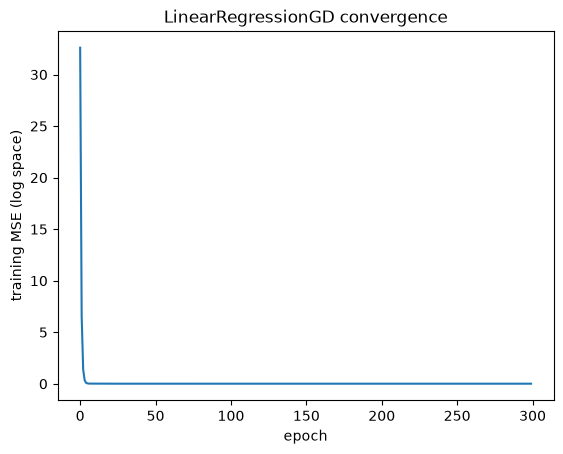

In [15]:
linreg_gd = LinearRegressionGD(
    learning_rate=0.01, batch_size=32, n_epochs=300, random_state=RANDOM_STATE,
)
linreg_gd.fit(X_train, y_train)

linreg_sk = LinearRegression()
linreg_sk.fit(X_train, y_train)

plt.plot(linreg_gd.loss_history_)
plt.xlabel("epoch")
plt.ylabel("training MSE (log space)")
plt.title("LinearRegressionGD convergence")
plt.show()


### 4.3 Ridge & Lasso: sweep alpha on the single split

Two different ranges, for reasons found by running this sweep rather
than assumed up front: over `np.logspace(-3, 1, 9)`, scikit-learn's
`Ridge` RMSE decreases monotonically with no interior minimum -- its
best alpha sits near 30, past that range -- while `RidgeGD`'s
fixed-learning-rate gradient descent diverges above roughly alpha=70.
So only scikit-learn `Ridge` sweeps the wider `alphas_sk`; `RidgeGD`,
`LassoGD`, and scikit-learn `Lasso` all show a clean interior minimum on
the narrower `alphas_gd` and sweep that directly.

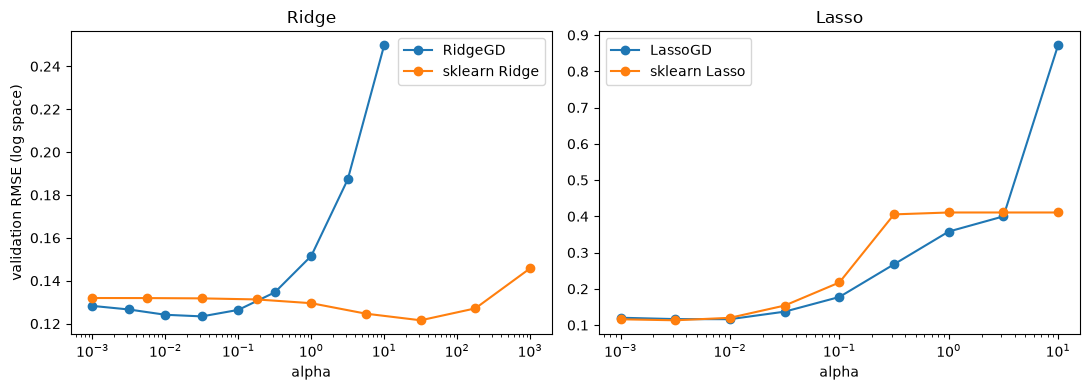

In [16]:
alphas_gd = np.logspace(-3, 1, 9)
alphas_sk = np.logspace(-3, 3, 9)

ridge_gd_rmse, lasso_gd_rmse, lasso_sk_rmse = [], [], []
for a in alphas_gd:
    ridge_gd = RidgeGD(learning_rate=0.01, batch_size=32, n_epochs=300,
                        alpha=a, random_state=RANDOM_STATE)
    ridge_gd.fit(X_train, y_train)
    ridge_gd_rmse.append(rmse(y_val, ridge_gd.predict(X_val)))

    lasso_gd = LassoGD(learning_rate=0.01, batch_size=32, n_epochs=300,
                        alpha=a, random_state=RANDOM_STATE)
    lasso_gd.fit(X_train, y_train)
    lasso_gd_rmse.append(rmse(y_val, lasso_gd.predict(X_val)))

    lasso_sk = Lasso(alpha=a)
    lasso_sk.fit(X_train, y_train)
    lasso_sk_rmse.append(rmse(y_val, lasso_sk.predict(X_val)))

ridge_sk_rmse = []
for a in alphas_sk:
    ridge_sk = Ridge(alpha=a)
    ridge_sk.fit(X_train, y_train)
    ridge_sk_rmse.append(rmse(y_val, ridge_sk.predict(X_val)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(alphas_gd, ridge_gd_rmse, marker="o", label="RidgeGD")
axes[0].semilogx(alphas_sk, ridge_sk_rmse, marker="o", label="sklearn Ridge")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("validation RMSE (log space)")
axes[0].legend()
axes[0].set_title("Ridge")

axes[1].semilogx(alphas_gd, lasso_gd_rmse, marker="o", label="LassoGD")
axes[1].semilogx(alphas_gd, lasso_sk_rmse, marker="o", label="sklearn Lasso")
axes[1].set_xlabel("alpha")
axes[1].legend()
axes[1].set_title("Lasso")
plt.tight_layout()
plt.show()


In [17]:
best_ridge_gd_alpha = alphas_gd[np.argmin(ridge_gd_rmse)]
best_ridge_sk_alpha = alphas_sk[np.argmin(ridge_sk_rmse)]
best_lasso_gd_alpha = alphas_gd[np.argmin(lasso_gd_rmse)]
best_lasso_sk_alpha = alphas_gd[np.argmin(lasso_sk_rmse)]

ridge_gd_best = RidgeGD(learning_rate=0.01, batch_size=32, n_epochs=300,
                         alpha=best_ridge_gd_alpha, random_state=RANDOM_STATE)
ridge_gd_best.fit(X_train, y_train)
ridge_sk_best = Ridge(alpha=best_ridge_sk_alpha)
ridge_sk_best.fit(X_train, y_train)
lasso_gd_best = LassoGD(learning_rate=0.01, batch_size=32, n_epochs=300,
                         alpha=best_lasso_gd_alpha, random_state=RANDOM_STATE)
lasso_gd_best.fit(X_train, y_train)
lasso_sk_best = Lasso(alpha=best_lasso_sk_alpha)
lasso_sk_best.fit(X_train, y_train)

(best_ridge_gd_alpha, best_ridge_sk_alpha, best_lasso_gd_alpha, best_lasso_sk_alpha)


(np.float64(0.03162277660168379),
 np.float64(31.622776601683793),
 np.float64(0.01),
 np.float64(0.0031622776601683794))

### 4.4 ElasticNet: sweep (alpha, l1_ratio) on the single split

A 2D grid, narrower than Ridge/Lasso's 9-point sweep since there are now
two hyperparameters (5x5 = 25 combinations).

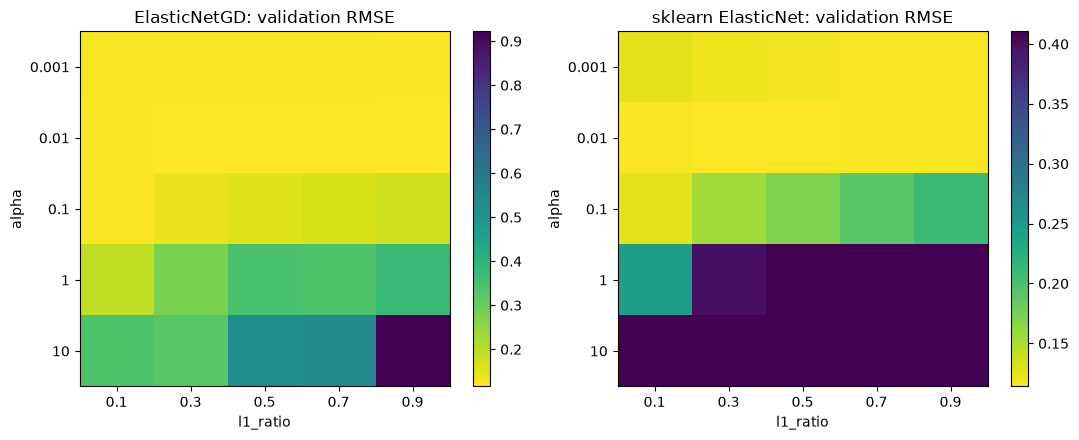

In [18]:
alphas_en = np.logspace(-3, 1, 5)
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

en_gd_rmse = np.zeros((len(alphas_en), len(l1_ratios)))
en_sk_rmse = np.zeros((len(alphas_en), len(l1_ratios)))
for i, a in enumerate(alphas_en):
    for j, r in enumerate(l1_ratios):
        en_gd = ElasticNetGD(learning_rate=0.01, batch_size=32, n_epochs=300,
                              alpha=a, l1_ratio=r, random_state=RANDOM_STATE)
        en_gd.fit(X_train, y_train)
        en_gd_rmse[i, j] = rmse(y_val, en_gd.predict(X_val))

        en_sk = ElasticNet(alpha=a, l1_ratio=r)
        en_sk.fit(X_train, y_train)
        en_sk_rmse[i, j] = rmse(y_val, en_sk.predict(X_val))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, data, title in [(axes[0], en_gd_rmse, "ElasticNetGD"),
                         (axes[1], en_sk_rmse, "sklearn ElasticNet")]:
    im = ax.imshow(data, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(l1_ratios))); ax.set_xticklabels(l1_ratios)
    ax.set_yticks(range(len(alphas_en))); ax.set_yticklabels([f"{a:.4g}" for a in alphas_en])
    ax.set_xlabel("l1_ratio"); ax.set_ylabel("alpha")
    ax.set_title(f"{title}: validation RMSE")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


In [19]:
best_en_gd_idx = np.unravel_index(np.argmin(en_gd_rmse), en_gd_rmse.shape)
best_en_sk_idx = np.unravel_index(np.argmin(en_sk_rmse), en_sk_rmse.shape)
best_en_gd_alpha, best_en_gd_l1_ratio = alphas_en[best_en_gd_idx[0]], l1_ratios[best_en_gd_idx[1]]
best_en_sk_alpha, best_en_sk_l1_ratio = alphas_en[best_en_sk_idx[0]], l1_ratios[best_en_sk_idx[1]]

en_gd_best = ElasticNetGD(learning_rate=0.01, batch_size=32, n_epochs=300,
                           alpha=best_en_gd_alpha, l1_ratio=best_en_gd_l1_ratio,
                           random_state=RANDOM_STATE)
en_gd_best.fit(X_train, y_train)
en_sk_best = ElasticNet(alpha=best_en_sk_alpha, l1_ratio=best_en_sk_l1_ratio)
en_sk_best.fit(X_train, y_train)

(best_en_gd_alpha, best_en_gd_l1_ratio, best_en_sk_alpha, best_en_sk_l1_ratio)


(np.float64(0.01), 0.7, np.float64(0.01), 0.3)

### 4.5 Cross-validated confirmation (winning model)

Every alpha above was picked on one 80/20 split -- a single lucky/unlucky
split could tip the observed minimum. `kfold_split` (this project's own
from-scratch k-fold index splitter) drives a 5-fold check on the
apparent winner, scikit-learn `Lasso`: a fresh `build_pipeline()` and a
fresh model are fit inside every fold, so no statistic leaks between
folds.

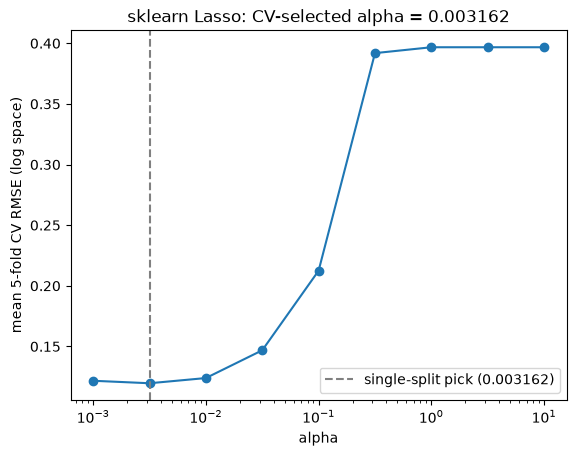

single-split alpha: 0.003162, CV-selected alpha: 0.003162


In [20]:
def cv_scores(model_cls, model_kwargs, X_raw, y, n_splits=5, random_state=RANDOM_STATE):
    fold_rmses = []
    for train_idx, val_idx in kfold_split(len(X_raw), n_splits, random_state):
        fold_pipeline = build_pipeline()
        X_fold_train = fold_pipeline.fit_transform(X_raw.iloc[train_idx]).to_numpy()
        X_fold_val = fold_pipeline.transform(X_raw.iloc[val_idx]).to_numpy()
        model = model_cls(**model_kwargs)
        model.fit(X_fold_train, y[train_idx])
        fold_rmses.append(rmse(y[val_idx], model.predict(X_fold_val)))
    return np.array(fold_rmses)


cv_pool_raw, _, y_cv_pool, _ = train_test_split(
    X_raw, y, test_size=0.2, random_state=RANDOM_STATE
)

lasso_sk_cv_alphas = alphas_gd
lasso_sk_cv_means = [
    cv_scores(Lasso, {"alpha": a}, cv_pool_raw, y_cv_pool).mean()
    for a in lasso_sk_cv_alphas
]
best_cv_alpha = lasso_sk_cv_alphas[np.argmin(lasso_sk_cv_means)]

plt.semilogx(lasso_sk_cv_alphas, lasso_sk_cv_means, marker="o")
plt.axvline(best_lasso_sk_alpha, color="gray", linestyle="--",
            label=f"single-split pick ({best_lasso_sk_alpha:.4g})")
plt.xlabel("alpha")
plt.ylabel("mean 5-fold CV RMSE (log space)")
plt.legend()
plt.title(f"sklearn Lasso: CV-selected alpha = {best_cv_alpha:.4g}")
plt.show()

print(f"single-split alpha: {best_lasso_sk_alpha:.4g}, CV-selected alpha: {best_cv_alpha:.4g}")


5-fold CV picks the identical alpha the single 80/20 split did -- a
reassuring sign that the single-split choice wasn't a lucky artifact of
that particular split. (The source repo's own `4_cross_validation.ipynb`
runs this same check across all six regularized model variants, not
just the winner shown here, for a fuller picture -- only `Ridge` shifted
there, toward more regularization.)

## 5. Testing / Evaluation

All seven fitted models, scored on the same held-out validation split.
RMSE in log space is what actually matters (it's what the Kaggle metric,
RMSLE, reduces to when the target is `log1p`-transformed); RMSE in
dollars and MAPE are included only for human-readable intuition.

In [21]:
MODELS = [
    ("LinearRegressionGD (baseline)", linreg_gd),
    ("sklearn LinearRegression (baseline)", linreg_sk),
    (f"RidgeGD (alpha={best_ridge_gd_alpha:.4g})", ridge_gd_best),
    (f"sklearn Ridge (alpha={best_ridge_sk_alpha:.4g})", ridge_sk_best),
    (f"LassoGD (alpha={best_lasso_gd_alpha:.4g})", lasso_gd_best),
    (f"sklearn Lasso (alpha={best_lasso_sk_alpha:.4g}, CV-confirmed)", lasso_sk_best),
    (f"ElasticNetGD (alpha={best_en_gd_alpha:.4g}, l1_ratio={best_en_gd_l1_ratio})", en_gd_best),
    (f"sklearn ElasticNet (alpha={best_en_sk_alpha:.4g}, l1_ratio={best_en_sk_l1_ratio})", en_sk_best),
]

metrics_rows = []
for name, model in MODELS:
    preds_log = model.predict(X_val)
    preds_dollars = np.expm1(preds_log)
    actual_dollars = np.expm1(y_val)
    metrics_rows.append({
        "model": name,
        "RMSE (log space)": rmse(y_val, preds_log),
        "RMSE (dollars, intuition only)": rmse(actual_dollars, preds_dollars),
        "R^2": r2_score(y_val, preds_log),
        "MAE (log space)": mean_absolute_error(y_val, preds_log),
        "MAPE (% of actual price)": 100 * mean_absolute_percentage_error(actual_dollars, preds_dollars),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index("model").sort_values("RMSE (log space)")
metrics_df


,RMSE (log space),"RMSE (dollars, intuition only)",R^2,MAE (log space),MAPE (% of actual price)
model,,,,,
"sklearn Lasso (alpha=0.003162, CV-confirmed)",0.113262,19109.196989,0.923902,0.081730,8.410651
"sklearn ElasticNet (alpha=0.01, l1_ratio=0.3)",0.113979,19287.215011,0.922935,0.082237,8.466782
"ElasticNetGD (alpha=0.01, l1_ratio=0.7)",0.115441,19429.647187,0.920947,0.081893,8.461866
LassoGD (alpha=0.01),0.116306,19422.823774,0.919757,0.082283,8.517492
sklearn Ridge (alpha=31.62),0.121564,21327.634963,0.912337,0.086978,8.962240
RidgeGD (alpha=0.03162),0.123382,21625.070301,0.909696,0.087814,9.058214
LinearRegressionGD (baseline),0.129316,22150.880483,0.900801,0.089412,9.112843
sklearn LinearRegression (baseline),0.131956,21996.366199,0.896710,0.089983,9.127959


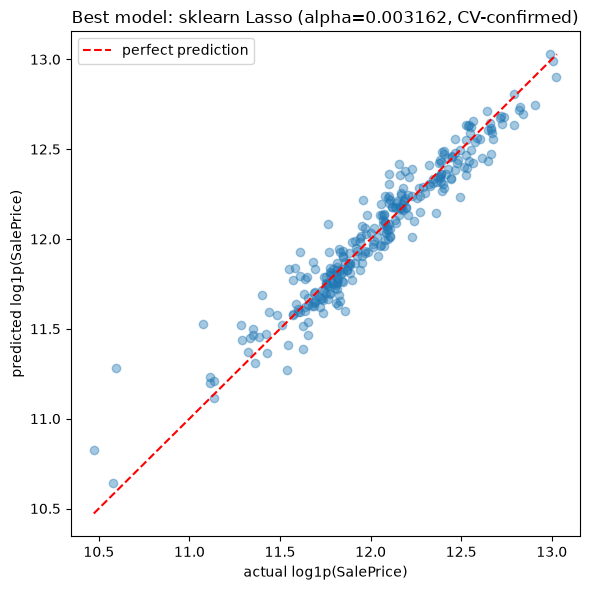

Best model on this holdout: sklearn Lasso (alpha=0.003162, CV-confirmed)


,RMSE (log space),"RMSE (dollars, intuition only)",R^2,MAE (log space),MAPE (% of actual price)
model,,,,,
"sklearn Lasso (alpha=0.003162, CV-confirmed)",0.113262,19109.196989,0.923902,0.08173,8.410651


In [22]:
best_model_name = metrics_df.index[0]
best_model = dict(MODELS)[best_model_name]
preds_log = best_model.predict(X_val)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_val, preds_log, alpha=0.4)
lims = [min(y_val.min(), preds_log.min()), max(y_val.max(), preds_log.max())]
ax.plot(lims, lims, color="red", linestyle="--", label="perfect prediction")
ax.set_xlabel("actual log1p(SalePrice)")
ax.set_ylabel("predicted log1p(SalePrice)")
ax.set_title(f"Best model: {best_model_name}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best model on this holdout: {best_model_name}")
metrics_df.loc[[best_model_name]]


## 6. Final refit & Kaggle submission

The winning model is refit on the *full* training data (outliers
dropped, no held-out validation slice) -- standard practice for a final
submission, since there's nowhere left to use a held-out slice once
hyperparameters are chosen.

In [23]:
X_test_raw = df_test[FEATURE_COLS]

final_pipeline = build_pipeline()
X_train_full = final_pipeline.fit_transform(X_raw).to_numpy()
X_test = final_pipeline.transform(X_test_raw).to_numpy()

final_model = Lasso(alpha=best_lasso_sk_alpha)
final_model.fit(X_train_full, y)

log_pred = final_model.predict(X_test)
sale_price_pred = np.expm1(log_pred)
pd.Series(sale_price_pred).describe()


count      1459.000000
mean     178061.599264
std       74590.786542
min       40153.474646
25%      127084.170166
50%      157462.793043
75%      212318.882821
max      672434.664376
dtype: float64

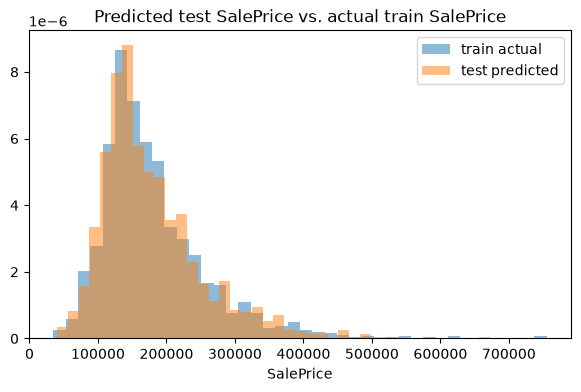

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_train_clean["SalePrice"], bins=40, alpha=0.5, density=True, label="train actual")
ax.hist(sale_price_pred, bins=40, alpha=0.5, density=True, label="test predicted")
ax.set_xlabel("SalePrice")
ax.legend()
ax.set_title("Predicted test SalePrice vs. actual train SalePrice")
plt.show()

assert (sale_price_pred > 0).all(), "negative predicted prices"


In [25]:
submission = pd.DataFrame({"Id": df_test["Id"], "SalePrice": sale_price_pred})
submission.to_csv("submission.csv", index=False)
submission.head()


,Id,SalePrice
0,1461,116510.472790
1,1462,156747.004222
2,1463,177329.572050
3,1464,191591.590007
4,1465,203654.051315


`submission.csv` is written next to this notebook -- on Kaggle, that's
the notebook's output directory, ready to submit directly from the
*Output* tab, or via *Submit to Competition*. Running this notebook
outside Kaggle writes it to the current working directory instead; join
the competition and use its *Submit Predictions* page, or the CLI:

```shell
kaggle competitions submit -c house-prices-advanced-regression-techniques \
  -f submission.csv -m "Lasso alpha=0.003162, full-pipeline features"
```


## 7. Conclusion & next steps

- scikit-learn `Lasso` (alpha=0.003162) is the best of the eight models
  compared, RMSE 0.113 (log space) / R² 0.924 on a held-out split,
  confirmed rather than contradicted by 5-fold cross-validation.
- The from-scratch gradient-descent models (`LinearRegressionGD`,
  `RidgeGD`, `LassoGD`, `ElasticNetGD`) track their scikit-learn
  counterparts closely, validating the from-scratch implementations
  against a trusted reference.
- **Not yet explored** (natural next steps): non-linear model families
  (tree ensembles / gradient boosting) to see how far linear
  regularization actually gets on this dataset; residual analysis to
  find which houses/price ranges the current best model misses; the
  handful of EDA items left open in the source repo's wrap-up notebook
  (e.g. resolving the `GarageYrBlt`/`YearBuilt` and
  `TotalBsmtSF`/parts redundancy with engineered features rather than a
  drop).

Full EDA (8 notebooks), preprocessing/feature-engineering source, and
per-model notebooks live in the
[source repository](https://github.com/akakritagya/ames-price).